# Predictive Maintenance — Equipment Failure Prediction
### Rhombix Technologies Data Science Internship
**Task 1: Data Preprocessing** &nbsp;|&nbsp; **Task 2: Feature Engineering**

**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Simulation (FD001 subset)
100 engines run to failure, 21 sensor channels + 3 operational settings, recorded per operating cycle.

The goal: predict **Remaining Useful Life (RUL)** / equipment failure risk from time-series sensor data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
%matplotlib inline


---
## Task 1 — Data Preprocessing


### 1.1 Load the raw data

In [2]:
# Column names per the official C-MAPSS documentation
index_names = ['unit_number', 'time_cycles']
setting_names = ['op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)

print(df.shape)
df.head()


(20631, 26)


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### 1.2 Basic inspection

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_number   20631 non-null  int64  
 1   time_cycles   20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-null  float64

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


### 1.3 Missing values

In [5]:
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
missing[missing > 0]


Total missing values: 0


Series([], dtype: int64)

C-MAPSS is a simulated dataset, so it has **no missing values** — but we still run this check
explicitly, because in a real-world sensor feed you would expect dropped readings and would need to
decide between forward-fill (sensor state persists between cycles), interpolation, or row removal.
The check-then-handle step is included here for completeness/reproducibility even though it's a no-op
on this dataset.

### 1.4 Drop constant / near-zero-variance sensors

In [6]:
# Sensors with (near) zero variance carry no predictive signal and can destabilize
# scaling / rolling-std calculations downstream — drop them.
stds = df[sensor_names + setting_names].std()
low_variance_cols = stds[stds < 1e-5].index.tolist()
print("Dropping low-variance columns:", low_variance_cols)

df = df.drop(columns=low_variance_cols)
sensor_names = [c for c in sensor_names if c not in low_variance_cols]
setting_names = [c for c in setting_names if c not in low_variance_cols]
df.shape


Dropping low-variance columns: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'op_setting_3']


(20631, 19)

### 1.5 Construct the target: Remaining Useful Life (RUL)

In [7]:
# Each unit runs until failure at its final recorded cycle.
# RUL at any given cycle = (max cycle for that engine) - (current cycle)
max_cycle = df.groupby('unit_number')['time_cycles'].transform('max')
df['RUL'] = max_cycle - df['time_cycles']

# Optional: clip RUL — degradation is typically negligible until the engine
# is close to failure, so many CMAPSS papers cap RUL at 125 to avoid the model
# wasting effort on the flat/healthy region. Keep both columns for flexibility.
RUL_CLIP = 125
df['RUL_clipped'] = df['RUL'].clip(upper=RUL_CLIP)

df[['unit_number', 'time_cycles', 'RUL', 'RUL_clipped']].head()


,unit_number,time_cycles,RUL,RUL_clipped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125


### 1.6 Binary failure-window label (classification target, optional)

In [8]:
# Useful if you want a classification framing instead of RUL regression:
# flag rows within N cycles of failure as "at risk"
FAILURE_WINDOW = 30
df['failure_within_30'] = (df['RUL'] <= FAILURE_WINDOW).astype(int)
df['failure_within_30'].value_counts(normalize=True)


failure_within_30
0    0.849741
1    0.150259
Name: proportion, dtype: float64

### 1.7 Scale sensor readings

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_cols = setting_names + sensor_names
df_scaled_vals = scaler.fit_transform(df[scaled_cols])
df[[f'{c}_scaled' for c in scaled_cols]] = df_scaled_vals

df.filter(like='_scaled').head()


,op_setting_1_scaled,op_setting_2_scaled,sensor_2_scaled,sensor_3_scaled,sensor_4_scaled,sensor_6_scaled,sensor_7_scaled,sensor_8_scaled,sensor_9_scaled,sensor_11_scaled,sensor_12_scaled,sensor_13_scaled,sensor_14_scaled,sensor_15_scaled,sensor_17_scaled,sensor_20_scaled,sensor_21_scaled
0,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


**Note on scaling order:** fit the scaler only on training data in a real train/test split
(here we're demonstrating on the full training file — when you add `test_FD001.txt`, reuse this
same fitted `scaler`, never refit on test data).

---
## Task 2 — Feature Engineering

Now we build features that expose *trends* and *rates of degradation*, not just instantaneous
sensor values — this is what actually gives a failure-prediction model something to learn from.


### 2.1 Time-based features

In [10]:
# Normalized cycle position (0 = start of life, 1 = failure) per engine.
# Lets the model learn "how far into its life" an engine is, independent of
# absolute cycle count, which varies engine-to-engine.
df['cycle_norm'] = df['time_cycles'] / max_cycle

# Cycles remaining as a fraction is a smoother alternative to raw cycle count.
df[['unit_number', 'time_cycles', 'cycle_norm']].head()


,unit_number,time_cycles,cycle_norm
0,1,1,0.005208
1,1,2,0.010417
2,1,3,0.015625
3,1,4,0.020833
4,1,5,0.026042


### 2.2 Rolling statistics (per engine, over a trailing window)

In [11]:
# Rolling mean/std smooth out sensor noise and reveal drift/instability that a
# single reading can't. Window size is a tunable hyperparameter — 5 cycles here
# as a starting point; try 10/20 and compare downstream model performance.
ROLL_WINDOW = 5

df = df.sort_values(['unit_number', 'time_cycles'])
grouped = df.groupby('unit_number')

roll_mean_cols = {}
roll_std_cols = {}
for s in sensor_names:
    roll_mean_cols[f'{s}_roll_mean{ROLL_WINDOW}'] = grouped[s].transform(
        lambda x: x.rolling(ROLL_WINDOW, min_periods=1).mean()
    )
    roll_std_cols[f'{s}_roll_std{ROLL_WINDOW}'] = grouped[s].transform(
        lambda x: x.rolling(ROLL_WINDOW, min_periods=1).std()
    )

df = pd.concat([df, pd.DataFrame(roll_mean_cols), pd.DataFrame(roll_std_cols)], axis=1)

# rolling std on the first reading of each engine is NaN (no window yet) — fill with 0
roll_std_names = list(roll_std_cols.keys())
df[roll_std_names] = df[roll_std_names].fillna(0)

df.filter(like='sensor_2_roll').head()


,sensor_2_roll_mean5,sensor_2_roll_std5
0,641.820000,0.000000
1,641.985000,0.233345
2,642.106667,0.267644
3,642.167500,0.250117
4,642.208000,0.234776


### 2.3 Lag features (previous-cycle readings)

In [12]:
# Gives the model direct access to "what was this sensor doing one/three cycles ago,"
# which helps capture short-term momentum in degradation that a rolling mean smooths away.
LAGS = [1, 3]
lag_frames = []
for lag in LAGS:
    lagged = grouped[sensor_names].shift(lag)
    lagged.columns = [f'{c}_lag{lag}' for c in sensor_names]
    lag_frames.append(lagged)

df = pd.concat([df] + lag_frames, axis=1)

lag_cols = [c for f in lag_frames for c in f.columns]
# Earliest cycles of each engine won't have a full lag history — backfill within engine
df[lag_cols] = grouped[lag_cols].transform(lambda x: x.bfill()) if False else df[lag_cols]
df[lag_cols] = df.groupby('unit_number')[lag_cols].bfill()

df.filter(like='sensor_2_lag').head()


,sensor_2_lag1,sensor_2_lag3
0,641.82,641.82
1,641.82,641.82
2,642.15,641.82
3,642.35,641.82
4,642.35,642.15


### 2.4 Rate-of-change / delta features

In [13]:
# First difference between consecutive cycles — a direct proxy for degradation *velocity*,
# which is often more predictive than the raw sensor level itself.
delta_frames = {}
for s in sensor_names:
    delta_frames[f'{s}_delta'] = grouped[s].diff().fillna(0)

df = pd.concat([df, pd.DataFrame(delta_frames)], axis=1)
df.filter(like='_delta').head()


,sensor_2_delta,sensor_3_delta,sensor_4_delta,sensor_6_delta,sensor_7_delta,sensor_8_delta,sensor_9_delta,sensor_11_delta,sensor_12_delta,sensor_13_delta,sensor_14_delta,sensor_15_delta,sensor_17_delta,sensor_20_delta,sensor_21_delta
0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000,0.0,0.00,0.0000
1,0.33,2.12,2.54,0.0,-0.61,-0.02,-2.12,0.02,0.62,0.05,-7.13,0.0123,0.0,-0.06,0.0046
2,0.20,-3.83,1.06,0.0,0.51,0.04,8.87,-0.22,0.14,-0.04,1.74,-0.0140,-2.0,-0.05,-0.0794
3,0.00,-5.20,-2.33,0.0,0.19,0.03,-3.46,-0.14,0.44,0.05,0.60,-0.0496,2.0,-0.07,0.0297
4,0.02,0.06,4.35,0.0,-0.45,-0.05,5.67,0.15,-0.67,-0.04,-0.03,0.0612,1.0,0.02,0.0305


### 2.5 Cumulative degradation features

In [14]:
# Cumulative sum of absolute deltas — a running "total wear" signal per engine,
# useful because instantaneous readings can be noisy but cumulative drift trends cleanly.
# Regroup: `grouped` was created before the delta columns existed, so it can't see them yet.
grouped_v2 = df.groupby('unit_number')

cum_frames = {}
for s in sensor_names:
    cum_frames[f'{s}_cumsum_abs_delta'] = grouped_v2[f'{s}_delta'].transform(lambda x: x.abs().cumsum())

df = pd.concat([df, pd.DataFrame(cum_frames)], axis=1)
df.filter(like='cumsum').head()


,sensor_2_cumsum_abs_delta,sensor_3_cumsum_abs_delta,sensor_4_cumsum_abs_delta,sensor_6_cumsum_abs_delta,sensor_7_cumsum_abs_delta,sensor_8_cumsum_abs_delta,sensor_9_cumsum_abs_delta,sensor_11_cumsum_abs_delta,sensor_12_cumsum_abs_delta,sensor_13_cumsum_abs_delta,sensor_14_cumsum_abs_delta,sensor_15_cumsum_abs_delta,sensor_17_cumsum_abs_delta,sensor_20_cumsum_abs_delta,sensor_21_cumsum_abs_delta
0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0000,0.0,0.00,0.0000
1,0.33,2.12,2.54,0.0,0.61,0.02,2.12,0.02,0.62,0.05,7.13,0.0123,0.0,0.06,0.0046
2,0.53,5.95,3.60,0.0,1.12,0.06,10.99,0.24,0.76,0.09,8.87,0.0263,2.0,0.11,0.0840
3,0.53,11.15,5.93,0.0,1.31,0.09,14.45,0.38,1.20,0.14,9.47,0.0759,4.0,0.18,0.1137
4,0.55,11.21,10.28,0.0,1.76,0.14,20.12,0.53,1.87,0.18,9.50,0.1371,5.0,0.20,0.1442


### 2.6 Feature set summary

In [15]:
engineered = (
    ['cycle_norm']
    + list(roll_mean_cols.keys()) + list(roll_std_cols.keys())
    + lag_cols
    + list(delta_frames.keys())
    + list(cum_frames.keys())
)
print(f"Original columns: {len(col_names)}")
print(f"Engineered features added: {len(engineered)}")
print(f"Total columns now: {df.shape[1]}")


Original columns: 26
Engineered features added: 91
Total columns now: 130


### 2.7 Quick sanity-check visualization

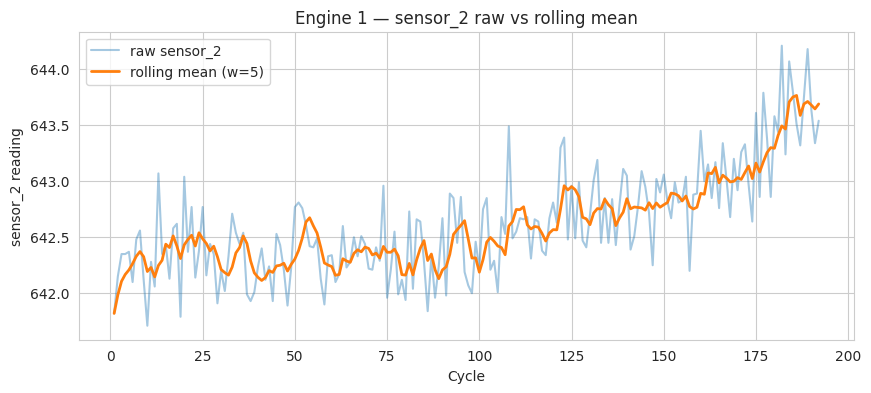

In [16]:
# Sensor 2 raw vs rolling mean for one engine — rolling mean should visibly smooth the trend
sample_engine = df[df['unit_number'] == 1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample_engine['time_cycles'], sample_engine['sensor_2'], alpha=0.4, label='raw sensor_2')
ax.plot(sample_engine['time_cycles'], sample_engine['sensor_2_roll_mean5'], linewidth=2, label='rolling mean (w=5)')
ax.set_xlabel('Cycle')
ax.set_ylabel('sensor_2 reading')
ax.set_title('Engine 1 — sensor_2 raw vs rolling mean')
ax.legend()
plt.show()


### 2.8 Save the processed + feature-engineered dataset

In [17]:
df.to_csv('cmapss_fd001_features.csv', index=False)
print("Saved:", df.shape)


Saved: (20631, 130)


---
## Next steps (not part of these two tasks, for later months)
- Train/test split **by engine ID** (never split mid-trajectory — that leaks future cycles into training)
- Feature selection / correlation pruning (many rolling+lag+delta columns will be highly correlated)
- Model training: start with Random Forest / Gradient Boosting for RUL regression, or the binary
  `failure_within_30` target for classification
